In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
import shap

In [3]:
df = pd.read_csv('https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv')
# making data column date type
df['date'] = pd.to_datetime(df['date'])
df['month'] = df.date.dt.month
df['year'] = df.date.dt.year
df.head()

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,ns,sn,sg,f1,f2,f3,f4,fc,month,year
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,1,1,1,25,0,0,0,0,10,1950
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,1,1,1,47,0,0,0,0,10,1950
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,1,1,1,177,0,0,0,0,11,1950
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,1,1,1,209,0,0,0,0,11,1950
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,1,1,1,101,0,0,0,0,11,1950


### 1. Aggregate the tornado data over the following states into a monthly count of tornadoes

In [4]:
# Illinois Indiana Wisconsin Michigan Missouri Iowa Minnesota
# creating month column
df['month'] = df.date.dt.month
grp_df = (df[df['st'].isin(['IL'])][
            ['st','year','month']].groupby(['year','month'])
            .count().reset_index())
grp_df.rename(columns={'st':'cnt'},inplace=True)
grp_df['date'] = (pd.to_datetime(grp_df['year'].astype(str) + '-'+\
                  grp_df['month'].astype(str).str.zfill(2) + '-' + '01'))
grp_df

,year,month,cnt,date
0,1950,1,2,1950-01-01
1,1950,3,1,1950-03-01
2,1950,6,1,1950-06-01
3,1950,7,1,1950-07-01
4,1950,12,3,1950-12-01
...,...,...,...,...
440,2021,6,15,2021-06-01
441,2021,7,8,2021-07-01
442,2021,8,16,2021-08-01
443,2021,10,10,2021-10-01


### 2. Merge this monthly tornado dataset with the ENSO, MJO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [5]:
wea_df = pd.read_csv('hw_data.csv')
wea_df['Date'] = pd.to_datetime(wea_df['Date'])
wea_df.rename(columns={'Date':'date'},inplace=True)
wea_df.head()

,date,ENSO,PDO,NAO,AO
0,1951-01-01,1.5,-1.19,0.08,-0.085
1,1951-02-01,0.9,-1.52,0.70,-0.400
2,1951-03-01,-0.1,-1.72,-1.02,-1.934
3,1951-04-01,-0.3,-1.35,-0.22,-0.776
4,1951-05-01,-0.7,-1.29,-0.59,-0.863


In [6]:
all_df = pd.merge(wea_df,grp_df,on='date',how='inner')
all_df.tail()

,date,ENSO,PDO,NAO,AO,year,month,cnt
435,2021-06-01,0.4,-1.82,0.77,0.845,2021,6,15
436,2021-07-01,1.4,-2.00,0.03,0.630,2021,7,8
437,2021-08-01,0.6,-0.95,-0.28,-0.209,2021,8,16
438,2021-10-01,0.7,-3.13,-2.29,-0.146,2021,10,10
439,2021-12-01,1.5,-2.71,0.29,0.198,2021,12,8


In [7]:
all_df.isnull().sum()

date     0
ENSO     0
PDO      0
NAO      0
AO       0
year     0
month    0
cnt      0
dtype: int64

### 3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes. Create a scatter plot of the predicted and observed number of tornadoes over these states. Report the correlation coefficient and RMSE of your model.

In [8]:
data_col = ['ENSO','PDO','NAO','AO','month']
X = all_df[data_col]
y = all_df['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)

In [10]:
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
pred_rf = model_rf.predict(X_test)

In [12]:
# rmse on test data
root_mean_squared_error(y_test, pred_rf)

11.48530647273843

In [13]:
pred_all = model_rf.predict(X)

In [14]:
# rmse on all data
root_mean_squared_error(y, pred_all)

5.779086177368749

In [15]:
# correlation
np.corrcoef(np.array(y),pred_all)[0][1]

np.float64(0.7477401283473735)

Text(0, 0.5, 'Predicted count')

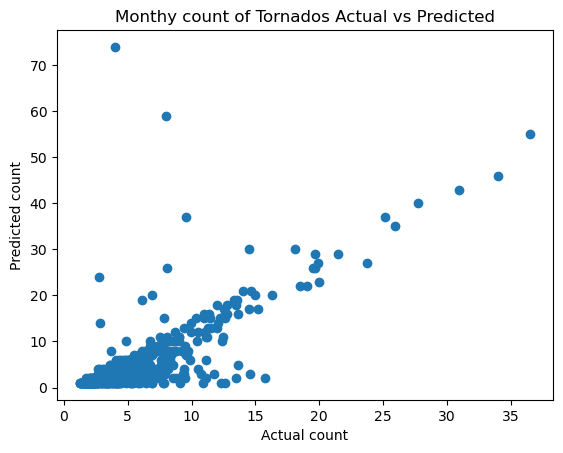

In [16]:
plt.scatter(pred_all,y)
plt.title("Monthy count of Tornados Actual vs Predicted")
plt.xlabel('Actual count')
plt.ylabel('Predicted count')

### 4. Create a one-hot encoding for the month of the year. Repeat the scatterplot and compare the RMSE and correlation coefficient values

In [17]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
month_encoded = encoder.fit_transform(all_df[['month']])
month_df = pd.DataFrame(month_encoded, columns=encoder.get_feature_names_out(['month']))
df_enc = pd.concat([all_df, month_df], axis=1)

In [18]:
df_enc.dropna(inplace=True)

In [19]:
df_enc.tail()

,date,ENSO,PDO,NAO,AO,year,month,cnt,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
435,2021-06-01,0.4,-1.82,0.77,0.845,2021,6,15,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
436,2021-07-01,1.4,-2.00,0.03,0.630,2021,7,8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
437,2021-08-01,0.6,-0.95,-0.28,-0.209,2021,8,16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
438,2021-10-01,0.7,-3.13,-2.29,-0.146,2021,10,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
439,2021-12-01,1.5,-2.71,0.29,0.198,2021,12,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
col_list2 = ['ENSO', 'PDO','NAO','AO','month_1','month_2','month_3','month_4','month_5',
            'month_6','month_7','month_8','month_9','month_10','month_11','month_12']

In [21]:
X_enc = df_enc[col_list2]
y_enc = df_enc['cnt']

In [22]:
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.2, random_state=42)

In [23]:
model_rf_enc = RandomForestRegressor(random_state=42)
model_rf_enc.fit(X_train_enc, y_train_enc)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
pred_rf_enc = model_rf_enc.predict(X_test_enc)

In [25]:
# rmse test data
root_mean_squared_error(y_test_enc, pred_rf_enc)

10.743193088056861

In [26]:
pred_all_enc = model_rf_enc.predict(X_enc)

In [27]:
# rmse on all data
root_mean_squared_error(y_enc, pred_all_enc)

5.511592452607174

In [28]:
# correlation
np.corrcoef(np.array(y_enc),pred_all_enc)[0][1]

np.float64(0.7835664314531525)

Text(0, 0.5, 'Predicted count')

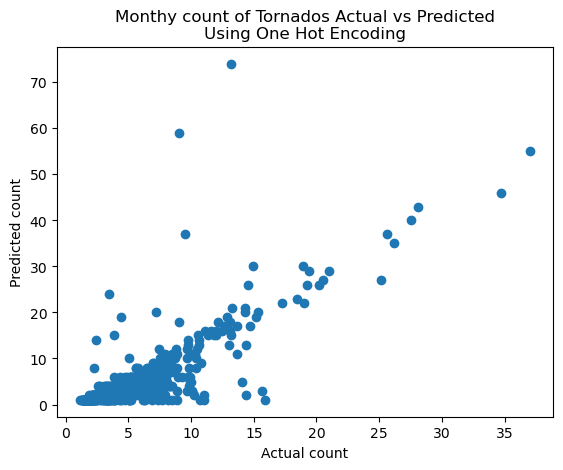

In [29]:
plt.scatter(pred_all_enc,y_enc)
plt.title("Monthy count of Tornados Actual vs Predicted\nUsing One Hot Encoding")
plt.xlabel('Actual count')
plt.ylabel('Predicted count')

### 5. Perform a feature importance and multipass permutation analysis of your features.

In [31]:
fea_imports = model_rf.feature_importances_
for i, imports in enumerate(fea_imports):
    col = X_train.columns[i]
    print(f"{col}: {imports:.4f}")

ENSO: 0.1759
PDO: 0.2225
NAO: 0.2390
AO: 0.2280
month: 0.1346


In [32]:
result = permutation_importance(
    model_rf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx],
)

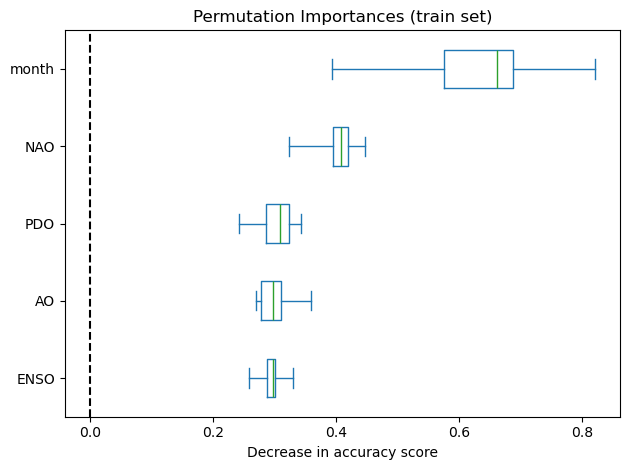

In [33]:
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

### 6. Create a SHAP Summary Plot showing feature importance and feature effects.

In [36]:
shap.initjs()
explainer = shap.TreeExplainer(model_rf, X_train,feature_names=X_train.columns)
shap_values = explainer(X_test,check_additivity=False)  # shap.Explanation
shap_values

.values =
array([[-7.53743324e-01, -4.26535007e-01, -5.89026663e-01,
        -3.65551679e-01, -1.35514336e+00],
       [ 1.04986498e+00,  2.07773327e-01, -9.17135020e-01,
         1.29148312e-01, -1.89965170e+00],
       [ 1.99599992e-01, -1.02922494e+00,  1.89333341e-01,
         7.60831604e-03,  8.02683216e-01],
       [ 5.31321659e-01, -2.95170008e-01, -8.71553347e-01,
        -2.19769998e-01, -1.84482835e+00],
       [ 4.15154970e-01, -8.25366837e-02, -4.39670020e-01,
        -6.58200216e-02,  2.61287165e+00],
       [-6.35456669e-01,  4.19918320e-01,  3.24385014e-01,
        -3.70706683e-01, -9.98140001e-01],
       [-1.39380499e+00, -4.27813344e-01, -4.74696652e-01,
         1.48858672e+00,  2.80772838e+00],
       [-5.50804976e-01,  3.80294977e-01, -1.90093836e+00,
         7.38928328e-01,  3.47252005e+00],
       [-3.07316669e-01,  1.45388330e+00,  1.51510006e+00,
         2.46158337e-01, -3.36782507e+00],
       [-1.18181502e+00,  1.07510021e-01,  1.98272672e+00,
        -1.04

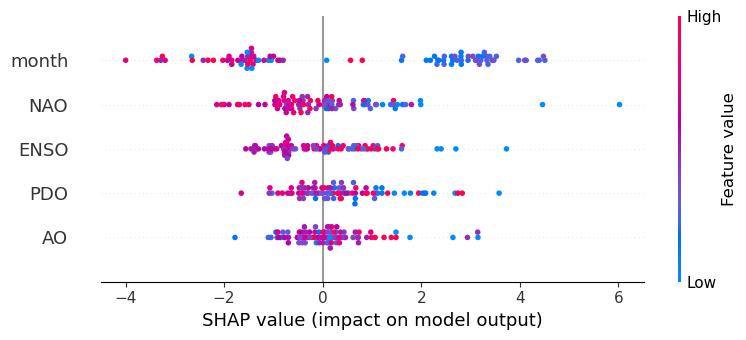

In [37]:
shap.summary_plot(shap_values,X_test)

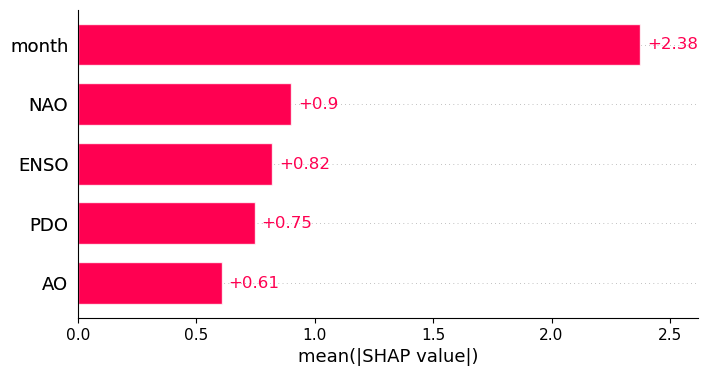

In [38]:
shap.plots.bar(shap_values, max_display=12)

### 7. Create a SHAP Feature Dependence for the ENSO index.

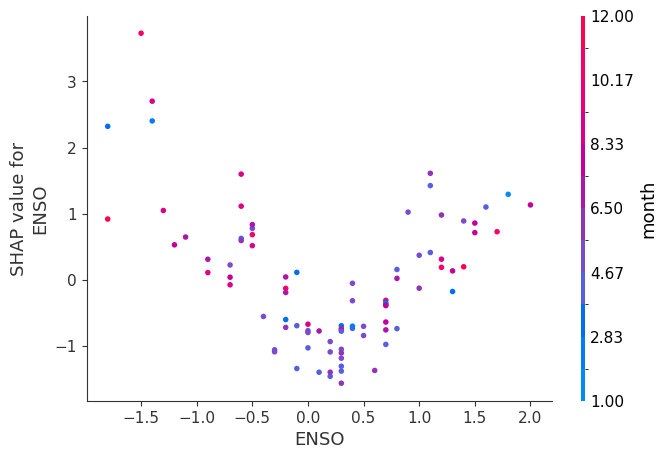

In [39]:
shap.dependence_plot("ENSO", shap_values.values,X_test)

### 8.Any observations on the importance of the various features in your model from the XAI techniques you tried?

When doing the feature importance from the random forest regressor the month is the least important feature.  When doing multipass permutation and shap analysis month is the most important feature.  Having the month being the most important feature makes a lot of sense to me.  The month feature acts as a seasonal indictor for a variety of other weather variables that are not included in the model. 